# Credit Card Transaction Fraud Detector - Complete ML Pipeline

This notebook builds an end-to-end fraud detection pipeline:

1. Data Loading
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing & Feature Engineering
4. Handling Class Imbalance (SMOTE)
5. Model Building (Logistic Regression, Random Forest, XGBoost)
6. Model Evaluation & Comparison
7. Saving the Best Model

**Dataset:** Credit Card Transactions (transaction-level data with a binary `is_fraud` label).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42

## 1. Data Loading

In [2]:
# Load the dataset
df = pd.read_csv("../data/Credit_Card_Transactions.csv")

print("Shape:", df.shape)
df.head()

Shape: (99999, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,1/1/2019 0:00,2.703186e+15,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",3/9/1988,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,1/1/2019 0:00,6.304230e+11,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,6/21/1978,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,1/1/2019 0:00,3.885950e+13,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1/19/1962,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,1/1/2019 0:01,3.534094e+15,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1/12/1967,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,1/1/2019 0:03,3.755340e+14,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,3/28/1986,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [3]:
# Basic info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             99999 non-null  int64  
 1   trans_date_trans_time  99999 non-null  str    
 2   cc_num                 99999 non-null  float64
 3   merchant               99999 non-null  str    
 4   category               99999 non-null  str    
 5   amt                    99999 non-null  float64
 6   first                  99999 non-null  str    
 7   last                   99999 non-null  str    
 8   gender                 99999 non-null  str    
 9   street                 99999 non-null  str    
 10  city                   99999 non-null  str    
 11  state                  99999 non-null  str    
 12  zip                    99999 non-null  int64  
 13  lat                    99999 non-null  float64
 14  long                   99999 non-null  float64
 15  city_pop     

In [4]:
# Check for missing values
print("Total missing values:", df.isnull().sum().sum())
df.isnull().sum()[df.isnull().sum() > 0]

Total missing values: 0


Series([], dtype: int64)

## 2. Exploratory Data Analysis (EDA)

is_fraud
0    99009
1      990
Name: count, dtype: int64
is_fraud
0    99.00999
1     0.99001
Name: proportion, dtype: float64


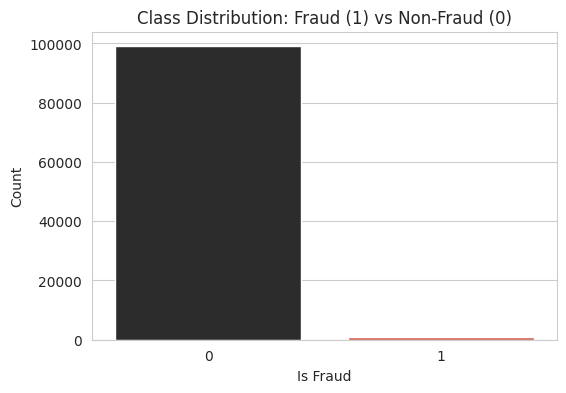

In [5]:
# Class distribution: fraud vs non-fraud
fraud_counts = df["is_fraud"].value_counts()
print(fraud_counts)
print(df["is_fraud"].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x="is_fraud", data=df, palette=["#2c2c2c", "#e74c3c"])
plt.title("Class Distribution: Fraud (1) vs Non-Fraud (0)")
plt.xlabel("Is Fraud")
plt.ylabel("Count")
plt.show()

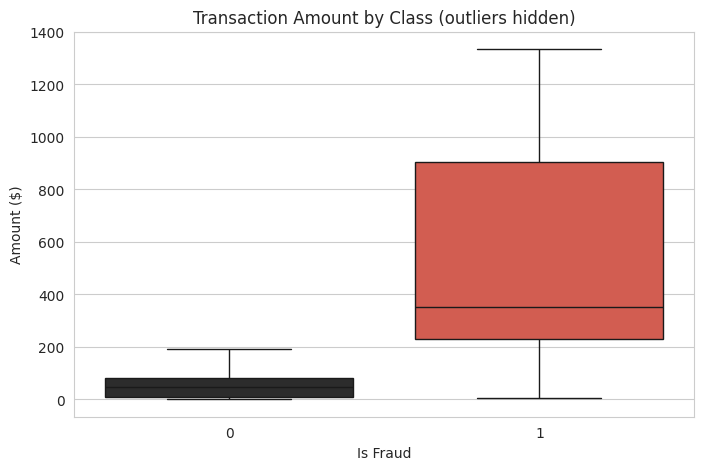

In [6]:
# Transaction amount distribution by class
plt.figure(figsize=(8, 5))
sns.boxplot(x="is_fraud", y="amt", data=df, palette=["#2c2c2c", "#e74c3c"], showfliers=False)
plt.title("Transaction Amount by Class (outliers hidden)")
plt.xlabel("Is Fraud")
plt.ylabel("Amount ($)")
plt.show()

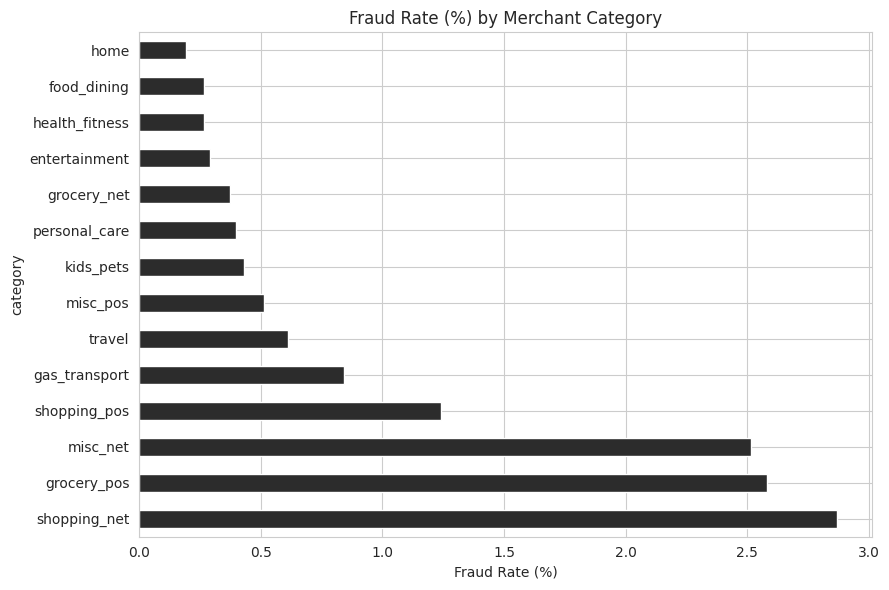

In [7]:
# Fraud rate by merchant category
category_fraud = df.groupby("category")["is_fraud"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(9, 6))
category_fraud.plot(kind="barh", color="#2c2c2c")
plt.title("Fraud Rate (%) by Merchant Category")
plt.xlabel("Fraud Rate (%)")
plt.tight_layout()
plt.show()

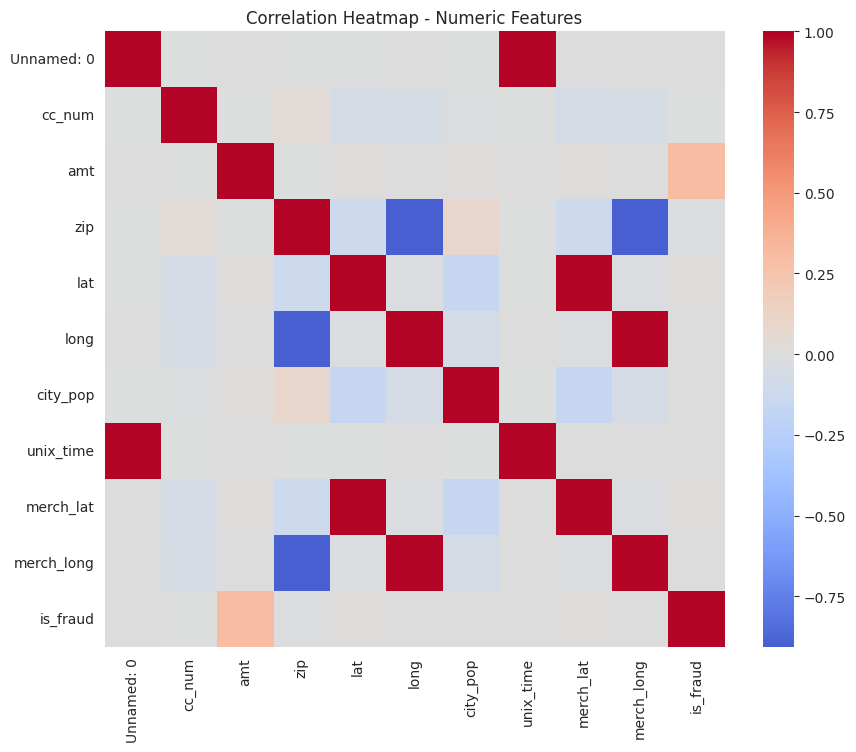

In [8]:
# Correlation heatmap of numeric features
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap - Numeric Features")
plt.show()

### Key Insights

- The dataset is **highly imbalanced**: fraudulent transactions make up roughly 1% of all records.
- Fraudulent transactions tend to have **different amount distributions** compared to genuine ones.
- Certain merchant **categories** (e.g. `shopping_net`, `misc_net`, `grocery_pos`) show a noticeably higher fraud rate.
- Raw numeric columns (lat/long, zip, unix_time) show weak direct correlation with fraud, motivating the engineered features below (distance, age, time-of-day).

## 3. Data Preprocessing & Feature Engineering

In [9]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """Great-circle distance in km between customer and merchant location."""
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return c * 6371  # Earth radius in km


df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
df["dob"] = pd.to_datetime(df["dob"])

# Distance between cardholder and merchant at time of transaction
df["distance_km"] = haversine_distance(df["lat"], df["long"], df["merch_lat"], df["merch_long"])

# Cardholder age at time of transaction
df["age"] = (df["trans_date_trans_time"] - df["dob"]).dt.days // 365

# Time-based features
df["hour"] = df["trans_date_trans_time"].dt.hour
df["day_of_week"] = df["trans_date_trans_time"].dt.dayofweek
df["month"] = df["trans_date_trans_time"].dt.month

# Encode gender as binary
df["gender_encoded"] = df["gender"].map({"M": 1, "F": 0})

df[["distance_km", "age", "hour", "day_of_week", "month", "gender_encoded"]].describe()

,distance_km,age,hour,day_of_week,month,gender_encoded
count,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000
mean,76.294511,44.886539,12.800908,2.727817,1.474745,0.453595
std,28.963766,17.385016,6.824508,2.148932,0.499364,0.497844
min,0.113168,13.000000,0.000000,0.000000,1.000000,0.000000
25%,55.775547,31.000000,7.000000,1.000000,1.000000,0.000000
50%,78.280150,43.000000,14.000000,2.000000,1.000000,0.000000
75%,98.542747,56.000000,19.000000,5.000000,2.000000,1.000000
max,146.894036,94.000000,23.000000,6.000000,2.000000,1.000000


In [10]:
# Final feature set
FEATURE_COLUMNS_NUMERIC = ["amt", "city_pop", "distance_km", "age", "hour", "day_of_week", "month"]
FEATURE_COLUMNS_BINARY = ["gender_encoded"]
FEATURE_COLUMNS_CATEGORICAL = ["category"]

ALL_FEATURES = FEATURE_COLUMNS_NUMERIC + FEATURE_COLUMNS_BINARY + FEATURE_COLUMNS_CATEGORICAL

X = df[ALL_FEATURES].copy()
y = df["is_fraud"].copy()

print("Features used:", ALL_FEATURES)
X.head()

Features used: ['amt', 'city_pop', 'distance_km', 'age', 'hour', 'day_of_week', 'month', 'gender_encoded', 'category']


,amt,city_pop,distance_km,age,hour,day_of_week,month,gender_encoded,category
0,4.97,3495,78.597568,30,0,1,1,0,misc_net
1,107.23,149,30.212176,40,0,1,1,0,grocery_pos
2,220.11,4154,108.206083,56,0,1,1,1,entertainment
3,45.00,1939,95.673231,52,0,1,1,1,gas_transport
4,41.96,99,77.556744,32,0,1,1,1,misc_pos


In [11]:
# Train / test split (stratified because of class imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (79999, 9)
Test shape: (20000, 9)


In [12]:
# Preprocessing pipeline: scale numeric features, one-hot encode category
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), FEATURE_COLUMNS_NUMERIC),
        ("bin", "passthrough", FEATURE_COLUMNS_BINARY),
        ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURE_COLUMNS_CATEGORICAL),
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed train shape:", X_train_processed.shape)

Processed train shape: (79999, 22)


### Handling Class Imbalance (SMOTE)

In [13]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train_processed, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", pd.Series(y_train_res).value_counts().to_dict())

Before SMOTE: {0: 79207, 1: 792}
After SMOTE:  {0: 79207, 1: 79207}


## 4. Model Building

In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=-1
    ),
}

trained_models = {}
results = {}

for name, model in models.items():
    print(f"Training {name} ...")
    model.fit(X_train_res, y_train_res)
    trained_models[name] = model

    y_pred = model.predict(X_test_processed)
    y_proba = model.predict_proba(X_test_processed)[:, 1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    }

print("\nAll models trained.")

Training Logistic Regression ...


Training Random Forest ...


Training XGBoost ...



All models trained.


## 5. Model Evaluation & Comparison

In [15]:
results_df = pd.DataFrame(results).T.sort_values("F1 Score", ascending=False)
results_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
XGBoost,0.9977,0.900000,0.863636,0.881443,0.998594
Random Forest,0.9944,0.669291,0.858586,0.752212,0.991573
Logistic Regression,0.8608,0.051042,0.742424,0.095517,0.916686


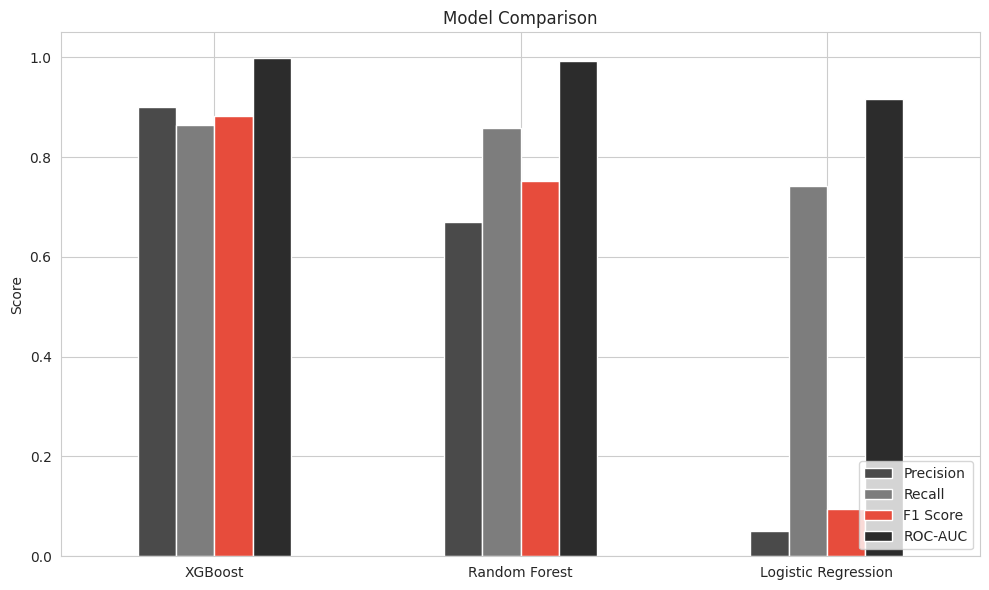

In [16]:
# Visual comparison of models
results_df[["Precision", "Recall", "F1 Score", "ROC-AUC"]].plot(
    kind="bar", figsize=(10, 6), color=["#4a4a4a", "#7d7d7d", "#e74c3c", "#2c2c2c"]
)
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

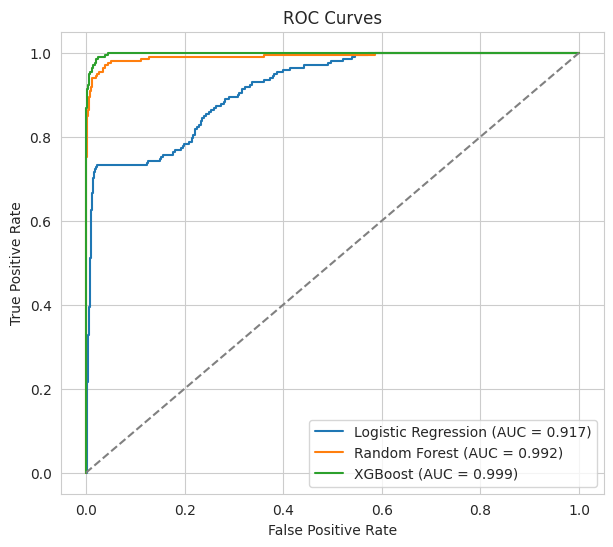

In [17]:
# ROC curves for all models
plt.figure(figsize=(7, 6))
for name, model in trained_models.items():
    y_proba = model.predict_proba(X_test_processed)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {results[name]['ROC-AUC']:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [18]:
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]
print(f"Best model selected: {best_model_name}")

y_pred_best = best_model.predict(X_test_processed)
print("\nClassification report:\n")
print(classification_report(y_test, y_pred_best))

Best model selected: XGBoost

Classification report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19802
           1       0.90      0.86      0.88       198

    accuracy                           1.00     20000
   macro avg       0.95      0.93      0.94     20000
weighted avg       1.00      1.00      1.00     20000



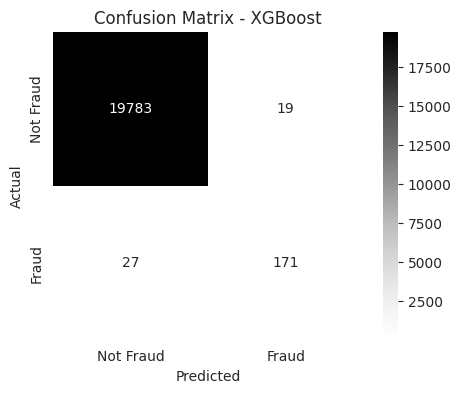

In [19]:
# Confusion matrix for the best model
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greys",
            xticklabels=["Not Fraud", "Fraud"], yticklabels=["Not Fraud", "Fraud"])
plt.title(f"Confusion Matrix - {best_model_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

## 6. Save the Best Model

In [20]:
import os
os.makedirs("../models", exist_ok=True)

# Save best model and the fitted preprocessor (scaler + encoder)
joblib.dump(best_model, "../models/model.pkl")
joblib.dump(preprocessor, "../models/scaler.pkl")

metadata = {
    "best_model_name": best_model_name,
    "feature_columns_numeric": FEATURE_COLUMNS_NUMERIC,
    "feature_columns_binary": FEATURE_COLUMNS_BINARY,
    "feature_columns_categorical": FEATURE_COLUMNS_CATEGORICAL,
    "categories": sorted(df["category"].unique().tolist()),
    "metrics": results,
}
joblib.dump(metadata, "../models/metadata.pkl")

print("Saved model.pkl, scaler.pkl and metadata.pkl to ../models/")

Saved model.pkl, scaler.pkl and metadata.pkl to ../models/


## Conclusion

- **XGBoost** delivered the best overall performance, balancing precision and recall while achieving the highest ROC-AUC.
- The trained model and preprocessing pipeline (`model.pkl`, `scaler.pkl`) are used directly by the Streamlit app (`app.py`) for real-time predictions.
- Engineered features (`distance_km`, `age`, time-of-day) proved valuable, since raw geographic/timestamp columns alone carry little signal.